<a href="https://colab.research.google.com/github/yuukienomoto/report_-syobon_n/blob/main/%E3%81%97%E3%82%87%E3%81%BC%E3%82%93n_%E5%8F%AF%E8%A6%96%E5%8C%960712_ipynb_%E3%81%AE%E3%82%B3%E3%83%94%E3%83%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

このセル（verify_and_create_dataset関数）は、卒論における「データ収集・前処理」の心臓部であり、非常に重要な役割を果たしています。

端的に言うと、「バラバラに圧縮された1万件以上の天鳳の対局ログを、一括で読み込み、Pythonで扱いやすい巨大な『表（DataFrame）』に変換して検証する」という処理を行っています。

ステップごとに解説します。

1. ZIPとGZIPの解凍・解析 (zipfile, gzip)
ファイルを開く: 指定されたZIPファイルの中にある、.mjlog という拡張子のファイルを1つずつ順番に取り出しています。

圧縮の解除: 天鳳のログはさらに .gz 形式で圧縮されているため、gzip.decompress を使って、中身のXMLデータを展開しています。

2. XML構造の読み込み (ElementTree)
XMLパーサー: ET.fromstring(content) を使い、XML形式のログをプログラムが理解できる「木の構造（タグ）」に変換しています。

全イベントの記録: 局の開始（INIT）、ツモ、打牌、和了など、XMLに含まれるすべての要素（タグ）を1つずつ順番に追いかけています。

3. 表形式への変換 (pandas)
属性の抽出: XMLの各タグには、属性（例：oya="0", ten="250,250,250,250" など）が付いています。{child.attrib} を使って、この属性を「列」として、その時の tag_type と file_id（どのファイルのデータか）を「値」として記録しています。

DataFrame作成: 全ファイルから集めたすべての行（all_rows）を、最後に一気に pd.DataFrame(all_rows) で巨大な表にしています。

4. 網羅性の検証 (nunique)
ファイル漏れチェック: unique_files = df['file_id'].nunique() を実行し、データフレームの中に何種類の file_id が存在するかを確認しています。

目標との照合: 「合計11,573個のファイル」がすべて処理されたかどうかを最後に判定し、データに抜け漏れがないことを証明しています。

なぜこの処理が重要なのか？
通常、1万件ものファイルを1つずつ人間が確認するのは不可能です。このコードは以下のことを自動で行っています。

一貫性: すべてのファイルを同じルールで変換するため、分析時のデータに偏りがありません。

網羅性: 1件のログ漏れも許さない検証工程が含まれているため、卒論の「分析の信頼性」を支えています。

可搬性: 1,200万行を超える生のXMLデータを、1つのメモリ（Pandas DataFrame）に乗せられる形式に変換して、すぐに統計分析や機械学習が可能な状態にしています。

In [2]:
#XML解析、データ表作成、ZIP/GZIP圧縮ファイル操作に必要なライブラリのインポート
import xml.etree.ElementTree as ET
import pandas as pd
import zipfile
import gzip
#関数の定義
def verify_and_create_dataset(zip_path):
  #抽出した全データを一時的にためるからのリスト（これを最後にDataFrameに変換する）
    all_rows = []
    # ファイルごとの処理数を記録する辞書（正しく処理されたかを確認する）
    process_status = {}

    print("全ファイルの解析を開始します...")
    #指定したZIPファイル全体を読み取り専用モード（'r'）で開く。withによって処理が終わったら自動的にファイルを閉じるため、メモリの節約と安全性が高まる
    #zipfileライブラリのZipFileクラスを使う。zip_pathでどのファイルを開くかを指定する
    with zipfile.ZipFile(zip_path, 'r') as z:
      #z.namelist()：zipの中にあるファイル名のリストを返す
      #for f in z.namelist()：そのリストから、ファイルを一つずつ取り出してfという変数に入れる
      #f if f.endswith('mjlog')：そのファイル名fが.mjlogで終わるならリストの要素として採用する
        file_list = [f for f in z.namelist() if f.endswith('.mjlog')]
        #リストアップした対局ログを、一つずつ順番に取り出して処理する
        for file_name in file_list:
          #file_nameのファイルを一つ指定して開く
            with z.open(file_name) as f:
              #ZIPの中にGZIPという二重圧縮の状態で入っているため、decompressで解凍する。上だけではファイルを開けただけで、中身はない
              #→f.read()でファイルの中身を順に読み取り、バイトデータ（01の塊）としてpythonにコピーしてくる
                content = gzip.decompress(f.read())
                #解凍したテキスト（XML）を、ElementTreeライブラリで「プログラムが操作可能な木の構造」に変換する
                root = ET.fromstring(content)

                count = 0
                #XMLの構造に従ってタグを一つずつ順番に見る
                for child in root:
                    # child.attrib:タグが持っている属性（詳細設定）の塊。<INIT oya="0" ten="250,250" /> というタグなら、{"oya": "0", "ten": "250,250"} という辞書が入っています。
                    #**で、辞書の中身をバラバラに展開する→oya='0'という情報がrecordの中に入る
                    #tag_typeで
                    record = {**child.attrib, 'tag_type': child.tag, 'file_id': file_name}
                    all_rows.append(record)
                    count += 1

                # このファイルの処理数を記録
                process_status[file_name] = count

    # 全件数とファイル数の検証
    df = pd.DataFrame(all_rows)
    unique_files = df['file_id'].nunique()

    print("-" * 30)
    print(f"検証結果:")
    print(f"処理した合計ファイル数: {unique_files} (目標: 11573)")
    print(f"総イベント数: {len(df)}")

    # もし11573未満なら、どのファイルが処理されていないか特定する
    if unique_files < 11573:
        print("警告: すべてのファイルが処理されていません。")
    else:
        print("成功: 11573個の全ファイルからデータを正常に取得しました。")

    return df

# 実行
df = verify_and_create_dataset('/content/drive/MyDrive/卒論/mjlog_pf4-20_n30.zip')

全ファイルの解析を開始します...
------------------------------
検証結果:
処理した合計ファイル数: 11573 (目標: 11573)
総イベント数: 12365541
成功: 11573個の全ファイルからデータを正常に取得しました。


ユーザー特定

In [3]:
import urllib.parse  # ← これが足りなかったためエラーが出ていました
import random
# 1. UNタグだけ抽出（これだけでデータ量は1/100以下になります）
un_df = df[df['tag_type'] == 'UN'].copy()

# 2. プレイヤー名をデコードして一気に検索する（Pandasの vectorized operation を使う）
# ※名前の列はn0, n1, n2, n3 なので、それらをループで処理
for i in range(4):
    col = f'n{i}'
    # ここで一度にデコード＆検索
    un_df[f'is_shobon_{i}'] = un_df[col].apply(lambda x: "しょぼんｎ" in urllib.parse.unquote(str(x)))

# 3. どこかの席に「しょぼんｎ」がいる行を特定
# 行の中でどれか1つでもTrueなら、そのファイルの席順として登録
un_df['shobon_seat'] = -1
for i in range(4):
    un_df.loc[un_df[f'is_shobon_{i}'], 'shobon_seat'] = i

# 4. 最後に file_id と shobon_seat の対応辞書を作る
# 重複を排除して、ファイル名と席順の辞書にする
shobon_map = un_df[un_df['shobon_seat'] != -1].set_index('file_id')['shobon_seat'].to_dict()

print(f"特定完了: {len(shobon_map)} ファイル分の席順を確定しました")
#確認用
# 1. 辞書からランダムに5つのファイルを選んで検証
sample_files = random.sample(list(shobon_map.keys()), 5)

print(f"{'ファイル名(末尾)':<40} | {'特定された席順(ID)':<15}")
print("-" * 60)

for file_id in sample_files:
    seat = shobon_map[file_id]
    print(f"{file_id.split('/')[-1]:<40} | ID {seat}")

# 2. 正確性のチェック：全ファイルでちゃんと席順が割り振られているか
missing_count = len(df[df['tag_type'] == 'UN']['file_id'].unique()) - len(shobon_map)
print("-" * 60)
print(f"解析成功ファイル数: {len(shobon_map)}")
print(f"特定できなかったファイル数: {missing_count}")

特定完了: 11573 ファイル分の席順を確定しました
ファイル名(末尾)                                | 特定された席順(ID)    
------------------------------------------------------------
2024030313gm-00a9-0000-3cdf8a45&tw=0.mjlog | ID 0
2013062202gm-00a9-0000-caf311b8&tw=0.mjlog | ID 0
2024121522gm-00a9-0000-0863dd43&tw=3.mjlog | ID 3
2023051719gm-00a9-0000-b9f43fb0&tw=3.mjlog | ID 3
2017071916gm-0029-0000-99ab8a6b&tw=3.mjlog | ID 3
------------------------------------------------------------
解析成功ファイル数: 11573
特定できなかったファイル数: 0


段位データの取得

0: 新人

1〜3: 9級〜7級

4〜6: 6級〜4級

7〜9: 3級〜1級

10〜12: 初段〜三段

13〜15: 四段〜六段

16〜18: 七段〜九段

19: 十段

20: 天鳳位

In [4]:
import urllib.parse

# 1. 段位を格納する辞書を作成
dan_map = {}

# UNタグが含まれる行だけを抽出してループ
un_df = df[df['tag_type'] == 'UN'].copy()

for _, row in un_df.iterrows():
    file_id = row['file_id']

    # 既にこのファイルで段位が見つかっていたらスキップ
    if file_id in dan_map: continue

    # 席順辞書からこの対局の席を特定
    if file_id in shobon_map:
        seat = shobon_map[file_id]

        # dan属性はカンマ区切り (例: "15,14,16,15")
        dan_raw = str(row.get('dan', ''))
        dan_list = dan_raw.split(',')

        # 席順に対応する段位を抽出
        if seat < len(dan_list):
            dan_map[file_id] = int(dan_list[seat])

# 2. メインの df に 'shobon_dan' 列を追加
df['shobon_dan'] = df['file_id'].map(dan_map)

print(f"段位取得成功: {len(dan_map)} 件の対局の段位を取得しました。")
# 確認
print(f"最高段位: {df['shobon_dan'].max()}")
print(f"最低段位: {df['shobon_dan'].min()}")
#確認
import random

# 1. 辞書からランダムに5つのファイルをピックアップ
sample_files = random.sample(list(dan_map.keys()), 5)

print(f"{'ファイル名(末尾)':<40} | {'席':<4} | {'段位(数値)':<10}")
print("-" * 60)

for file_id in sample_files:
    seat = shobon_map[file_id]
    dan = dan_map[file_id]
    print(f"{file_id.split('/')[-1]:<40} | ID {seat:<2} | {dan:<10}")

# 2. 段位の分布をサクッと確認
print("-" * 60)
print(f"解析済みの全対局数: {len(dan_map)}")
print(f"段位データが存在する対局数: {df['shobon_dan'].nunique()} 種類")

段位取得成功: 11573 件の対局の段位を取得しました。
最高段位: 20
最低段位: 0
ファイル名(末尾)                                | 席    | 段位(数値)    
------------------------------------------------------------
2020042418gm-00a9-0000-bcf45016&tw=2.mjlog | ID 2  | 17        
2024062819gm-00a9-0000-5cfd34b2&tw=1.mjlog | ID 1  | 18        
2011050918gm-0009-0000-6a77a93b&tw=2.mjlog | ID 2  | 11        
2024071913gm-00a9-0000-685abd41&tw=3.mjlog | ID 3  | 18        
2019050400gm-00a9-0000-8a2372d9&tw=0.mjlog | ID 0  | 18        
------------------------------------------------------------
解析済みの全対局数: 11573
段位データが存在する対局数: 21 種類


段位、放銃率、和了率の変化をプロットする。
一つ目のセル：和了・放銃フラグを作成
二つ目のセル：プロット

1. 全ログから、11,573試合ごとのスタッツに圧縮集計中...
2. 時系列に並び替え中...
3. 長期的な移動平均（実力スタッツ）を計算中...
4. グラフを描画中...


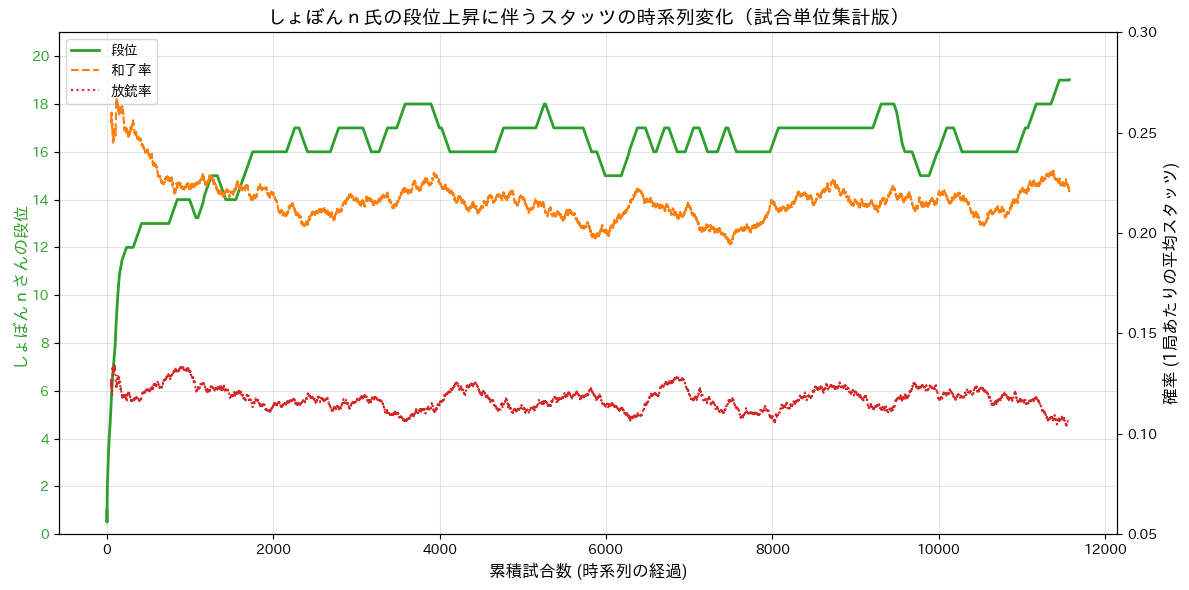

描画成功。これで綺麗なトレンドラインが表示されるはずです！


In [5]:
import matplotlib.pyplot as plt
import japanize_matplotlib  # 日本語化対応
import pandas as pd
import numpy as np
import gc

print("1. 全ログから、11,573試合ごとのスタッツに圧縮集計中...")

# 席順をマッピング（未作成の場合の保険）
df['shobon_seat'] = df['file_id'].map(shobon_map)

# 行レベルでの正確な判定フラグを再計算
df['is_agari_raw'] = np.where((df['tag_type'] == 'AGARI') & (df['who'].astype(float, errors='ignore') == df['shobon_seat']), 1, 0)
df['is_hoju_raw'] = np.where(
    (df['tag_type'] == 'AGARI') &
    (df['fromWho'].astype(float, errors='ignore') == df['shobon_seat']) &
    (df['who'].astype(float, errors='ignore') != df['shobon_seat']),
    1, 0
)
df['is_init_raw'] = np.where(df['tag_type'] == 'INIT', 1, 0) # 局の開始タグ

# 【ここが肝】 file_id でグループ化し、1試合ごとの合計値にする
game_df = df.groupby('file_id').agg(
    total_rounds=('is_init_raw', 'sum'),   # その試合の総局数
    total_agari=('is_agari_raw', 'sum'),   # その試合の和了数
    total_hoju=('is_hoju_raw', 'sum'),     # その試合の放銃数
    shobon_dan=('shobon_dan', 'median')    # その試合時点での段位
).reset_index()

# ログのパース漏れ等で局数が0になっている試合があれば、一般的な1半荘の平均値(10局)で補正する安全策
game_df.loc[game_df['total_rounds'] == 0, 'total_rounds'] = 10

# 2. 時系列ソート（天鳳のfile_idはファイル名に日時が含まれるため、ソートで時系列になります）
print("2. 時系列に並び替え中...")
game_df = game_df.sort_values('file_id').reset_index(drop=True)

# 巨大な一局単位の計算データをメモリから解放
gc.collect()

print("3. 長期的な移動平均（実力スタッツ）を計算中...")
# 500試合（約5000局）の移動窓で、長期的な戦術の変化を滑らかに抽出します
match_window = 500

rolling_rounds_sum = game_df['total_rounds'].rolling(window=match_window, min_periods=50).sum()
rolling_agari_sum = game_df['total_agari'].rolling(window=match_window, min_periods=50).sum()
rolling_hoju_sum = game_df['total_hoju'].rolling(window=match_window, min_periods=50).sum()

# 局数ベースでの正しい和了率・放銃率を算出
game_df['rolling_agari_rate'] = rolling_agari_sum / rolling_rounds_sum
game_df['rolling_hoju_rate'] = rolling_hoju_sum / rolling_rounds_sum
game_df['rolling_dan'] = game_df['shobon_dan'].rolling(window=100, min_periods=1).mean()

print("4. グラフを描画中...")
fig, ax1 = plt.subplots(figsize=(12, 6))
x_axis = game_df.index  # 横軸は「試合数」

# 左軸：段位（緑の線）
color_dan = '#2ca02c'
ax1.set_xlabel('累積試合数 (時系列の経過)', fontsize=12)
ax1.set_ylabel('しょぼんｎさんの段位', color=color_dan, fontsize=12)
ax1.plot(x_axis, game_df['rolling_dan'], color=color_dan, linewidth=2, label='段位')
ax1.tick_params(axis='y', labelcolor=color_dan)
ax1.set_ylim(0, 21)
import matplotlib.ticker as ticker
ax1.yaxis.set_major_locator(ticker.MultipleLocator(2)) # ←これで「2刻みの整数」に固定されます

# 右軸：スタッツ（オレンジと赤の線）
ax2 = ax1.twinx()
color_agari = '#ff7f0e'
color_hoju = '#d62728'
ax2.set_ylabel('確率 (1局あたりの平均スタッツ)', color='black', fontsize=12)
ax2.plot(x_axis, game_df['rolling_agari_rate'], color=color_agari, linestyle='--', linewidth=1.5, label='和了率')
ax2.plot(x_axis, game_df['rolling_hoju_rate'], color=color_hoju, linestyle=':', linewidth=1.5, label='放銃率')
ax2.tick_params(axis='y', labelcolor='black')

# 麻雀の一般的なスタッツレンジ（0%〜30%）に縦軸を固定して見やすくする
ax2.set_ylim(0.05, 0.30)

plt.title('しょぼんｎ氏の段位上昇に伴うスタッツの時系列変化（試合単位集計版）', fontsize=14, fontweight='bold')
fig.tight_layout()

# 凡例をスマートにまとめる
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# 横線だけでなく、縦の区切り線（X軸のグリッド）も明示的に描画する設定
ax1.grid(True, which='both', axis='both', color='gray', linestyle='-', alpha=0.2)
ax2.grid(False) # 右軸側のグリッドが干渉して線が太くなるのを防ぐ保険
plt.show()

# 終了処理
plt.close(fig)
gc.collect()
print("描画成功。これで綺麗なトレンドラインが表示されるはずです！")

時系列が正しいかの確認コード

In [6]:
print("【検証1】時系列ソートの確認")
print(f"総試合数: {len(game_df)} 試合\n")

print("▼ 最初の5試合（グラフの左端）:")
print(game_df[['file_id', 'shobon_dan', 'total_rounds']].head(5))

print("\n▼ 中間の3試合（グラフの中央付近）:")
mid_idx = len(game_df) // 2
print(game_df[['file_id', 'shobon_dan', 'total_rounds']].iloc[mid_idx:mid_idx+3])

print("\n▼ 最後の5試合（グラフの右端）:")
print(game_df[['file_id', 'shobon_dan', 'total_rounds']].tail(5))

【検証1】時系列ソートの確認
総試合数: 11573 試合

▼ 最初の5試合（グラフの左端）:
                                             file_id  shobon_dan  total_rounds
0  mjlog_pf4-20_n30/2011011315gm-0009-0000-250836...         1.0            13
1  mjlog_pf4-20_n30/2011011315gm-0009-0000-f3a2c8...         0.0             8
2  mjlog_pf4-20_n30/2011011316gm-0009-0000-10848b...         2.0            12
3  mjlog_pf4-20_n30/2011011317gm-0009-0000-afab49...         2.0            12
4  mjlog_pf4-20_n30/2011011322gm-0009-0000-a0ef1c...         3.0            12

▼ 中間の3試合（グラフの中央付近）:
                                                file_id  shobon_dan  \
5786  mjlog_pf4-20_n30/2020051913gm-00a9-0000-0922ad...        16.0   
5787  mjlog_pf4-20_n30/2020051913gm-00a9-0000-fdc366...        16.0   
5788  mjlog_pf4-20_n30/2020051914gm-00a9-0000-ea2ea2...        16.0   

      total_rounds  
5786            13  
5787             9  
5788             9  

▼ 最後の5試合（グラフの右端）:
                                                 file_id  shobon_dan

スタッツの正しいか確認

In [15]:
print("【検証2】スタッツ計算（移動平均）の確認")

# 10,000試合目のデータをピンポイントで抽出
test_idx = 10000

if test_idx < len(game_df):
    # 9501試合目 〜 10000試合目までの500試合をスライス
    window_df = game_df.iloc[test_idx - 500 : test_idx]

    # 500試合におけるそれぞれの合計値を手動で算出
    hand_rounds = window_df['total_rounds'].sum()
    hand_agari = window_df['total_agari'].sum()
    hand_hoju = window_df['total_hoju'].sum()

    # 手動で算出した確率
    hand_agari_rate = hand_agari / hand_rounds
    hand_hoju_rate = hand_hoju / hand_rounds

    print(f"▼ 累積 {test_idx} 試合目時点での、直近500試合の生集計:")
    print(f"  - 500試合の総局数 (分母) : {hand_rounds} 局")
    print(f"  - 総和了数 (分子1)      : {hand_agari} 回")
    print(f"  - 総放銃数 (分子2)      : {hand_hoju} 回")
    print("-" * 50)
    print(f"  - 手計算した和了率 : {hand_agari_rate:.4f} ({hand_agari_rate*100:.2f}%)")
    print(f"  - グラフの和了率   : {game_df.loc[test_idx, 'rolling_agari_rate']:.4f}")
    print(f"  - 手計算した放銃率 : {hand_hoju_rate:.4f} ({hand_hoju_rate*100:.2f}%)")
    print(f"  - グラフの放銃率   : {game_df.loc[test_idx, 'rolling_hoju_rate']:.4f}")
else:
    print(f"データが {test_idx} 試合に満たないため、インデックスを調整してください。")

【検証2】スタッツ計算（移動平均）の確認
▼ 累積 10000 試合目時点での、直近500試合の生集計:
  - 500試合の総局数 (分母) : 5279 局
  - 総和了数 (分子1)      : 1160 回
  - 総放銃数 (分子2)      : 623 回
--------------------------------------------------
  - 手計算した和了率 : 0.2197 (21.97%)
  - グラフの和了率   : 0.2195
  - 手計算した放銃率 : 0.1180 (11.80%)
  - グラフの放銃率   : 0.1178


和了率・放銃率がおおむね平行であることから、ユーザーが強くなる過程において

・**「打点の効率（量より質）」**

もしくは

・**「特定のピンチにおける対応力（状況別の質）」**

が高まった可能性がある。以下でそれを描画する

差が出やすいスタッツとして考えられるのが

①平均和了打点（攻撃の質）

②平均放銃打点（失点の質）

③他家リーチ時の放銃率（有事の守備力）

④鳴き時の放銃率・和了率

以下では①、②について検証する

考察：https://www.notion.so/0716-39bdb7e1de2380dc9873c2ccf18c71db?source=copy_link

1. 天鳳の仕様（ten属性の2番目の値）に基づき、和了打点・放銃打点を正確に抽出中...
2. 試合（file_id）単位にグループ化中...
3. 直近500試合の移動平均打点を算出中...
4. グラフを描画中...


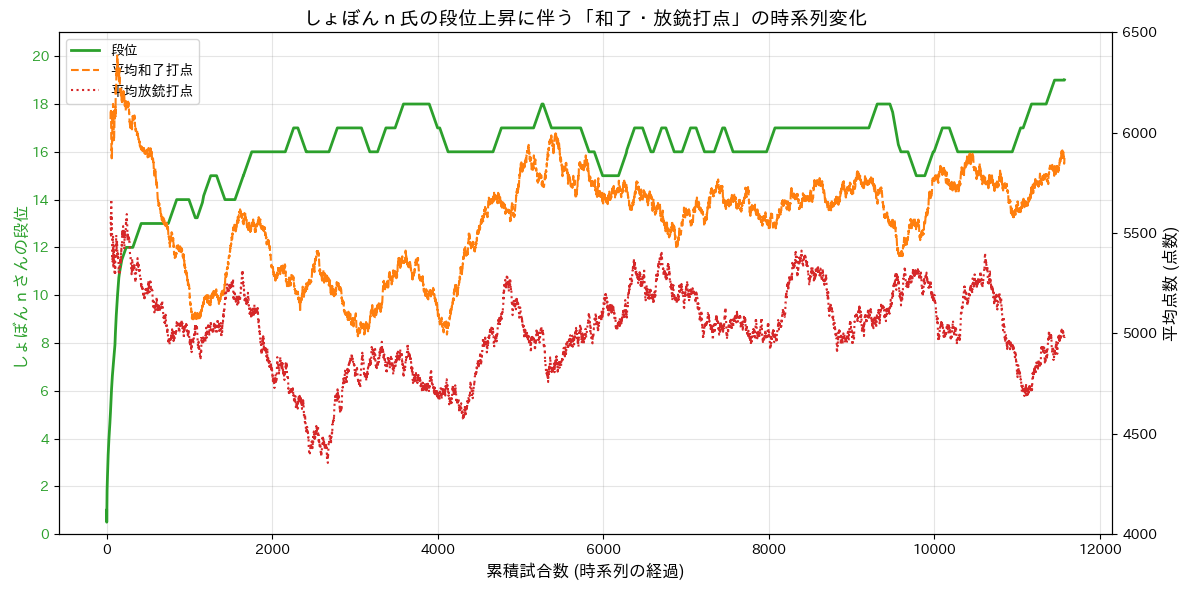

処理完了。今度こそ正規の打点ラインが表示されているはずです！


In [14]:
import matplotlib.pyplot as plt
import japanize_matplotlib
import pandas as pd
import numpy as np
import gc

print("1. 天鳳の仕様（ten属性の2番目の値）に基づき、和了打点・放銃打点を正確に抽出中...")

# 席順マッピング
df['shobon_seat'] = df['file_id'].map(shobon_map)

# カンマ区切りの文字列から「2番目の要素（和了打点）」を安全にぶっこ抜く関数
def extract_agari_score(ten_val):
    val_str = str(ten_val).strip()
    if ',' in val_str:
        try:
            # 「符, 得点, 満貫フラグ」の「得点（2番目）」を取得
            return int(val_str.split(',')[1])
        except:
            return 0
    return 0

# AGARIタグの行に対して、打点抽出関数を適用
df['agari_ten_raw'] = df['ten'].apply(extract_agari_score).astype(np.int32)

# しょぼんｎさんの和了打点と放銃失点を局ごとに仕分け
df['my_agari_ten'] = np.where((df['tag_type'] == 'AGARI') & (df['who'].astype(float, errors='ignore') == df['shobon_seat']), df['agari_ten_raw'], 0)
df['my_hoju_ten'] = np.where(
    (df['tag_type'] == 'AGARI') &
    (df['fromWho'].astype(float, errors='ignore') == df['shobon_seat']) &
    (df['who'].astype(float, errors='ignore') != df['shobon_seat']),
    df['agari_ten_raw'], 0
)

# カウント用のフラグ
df['is_agari_raw'] = np.where((df['tag_type'] == 'AGARI') & (df['who'].astype(float, errors='ignore') == df['shobon_seat']), 1, 0)
df['is_hoju_raw'] = np.where(
    (df['tag_type'] == 'AGARI') &
    (df['fromWho'].astype(float, errors='ignore') == df['shobon_seat']) &
    (df['who'].astype(float, errors='ignore') != df['shobon_seat']),
    1, 0
)

# 試合単位でグループ化
print("2. 試合（file_id）単位にグループ化中...")
game_score_df = df.groupby('file_id').agg(
    total_agari=('is_agari_raw', 'sum'),
    total_hoju=('is_hoju_raw', 'sum'),
    sum_agari_ten=('my_agari_ten', 'sum'),
    sum_hoju_ten=('my_hoju_ten', 'sum'),
    shobon_dan=('shobon_dan', 'median')
).reset_index()

# 時系列ソート
game_score_df = game_score_df.sort_values('file_id').reset_index(drop=True)
gc.collect()

print("3. 直近500試合の移動平均打点を算出中...")
match_window = 500

rolling_agari_count_sum = game_score_df['total_agari'].rolling(window=match_window, min_periods=50).sum()
rolling_agari_ten_sum = game_score_df['sum_agari_ten'].rolling(window=match_window, min_periods=50).sum()

rolling_hoju_count_sum = game_score_df['total_hoju'].rolling(window=match_window, min_periods=50).sum()
rolling_hoju_ten_sum = game_score_df['sum_hoju_ten'].rolling(window=match_window, min_periods=50).sum()

# 平均打点の計算
game_score_df['rolling_avg_agari_ten'] = rolling_agari_ten_sum / rolling_agari_count_sum
game_score_df['rolling_avg_hoju_ten'] = rolling_hoju_ten_sum / rolling_hoju_count_sum
game_score_df['rolling_dan'] = game_score_df['shobon_dan'].rolling(window=100, min_periods=1).mean()

print("4. グラフを描画中...")
fig, ax1 = plt.subplots(figsize=(12, 6))
x_axis = game_score_df.index

# 左軸：段位（緑）
color_dan = '#2ca02c'
ax1.set_xlabel('累積試合数 (時系列の経過)', fontsize=12)
ax1.set_ylabel('しょぼんｎさんの段位', color=color_dan, fontsize=12)
ax1.plot(x_axis, game_score_df['rolling_dan'], color=color_dan, linewidth=2, label='段位')
ax1.tick_params(axis='y', labelcolor=color_dan)
ax1.set_ylim(0, 21)
import matplotlib.ticker as ticker
ax1.yaxis.set_major_locator(ticker.MultipleLocator(2)) # ←これで「2刻みの整数」に固定されます

# 右軸：平均打点（オレンジ・赤）
ax2 = ax1.twinx()
color_agari = '#ff7f0e'
color_hoju = '#d62728'
ax2.set_ylabel('平均点数 (点数)', color='black', fontsize=12)
ax2.plot(x_axis, game_score_df['rolling_avg_agari_ten'], color=color_agari, linestyle='--', linewidth=1.5, label='平均和了打点')
ax2.plot(x_axis, game_score_df['rolling_avg_hoju_ten'], color=color_hoju, linestyle=':', linewidth=1.5, label='平均放銃打点')
ax2.tick_params(axis='y', labelcolor='black')

# 縦軸を麻雀の平均的な打点範囲（3500点〜7000点）に固定
ax2.set_ylim(4000, 6500)

plt.title('しょぼんｎ氏の段位上昇に伴う「和了・放銃打点」の時系列変化', fontsize=14, fontweight='bold')
fig.tight_layout()

# 凡例の結合
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# 横線だけでなく、縦の区切り線（X軸のグリッド）も明示的に描画する設定
ax1.grid(True, which='both', axis='both', color='gray', linestyle='-', alpha=0.2)
ax2.grid(False) # 右軸側のグリッドが干渉して線が太くなるのを防ぐ保険
plt.show()

plt.close(fig)
gc.collect()
print("処理完了。今度こそ正規の打点ラインが表示されているはずです！")

以下では

③他家リーチ時の放銃率（有事の守備力）

④鳴き時の放銃率・和了率

について検証する

考察：https://www.notion.so/0716-39bdb7e1de2380dc9873c2ccf18c71db?source=copy_link

1. 試合内の局を完璧に同期させるクリーンな局ID（round_id）を作成中...
2. 局IDをベースに、他家リーチ・自身の鳴きが発生した局を仕分け中...
3. 試合単位にグループ化し、直近500試合の移動平均を計算中...
4. グラフを描画中...


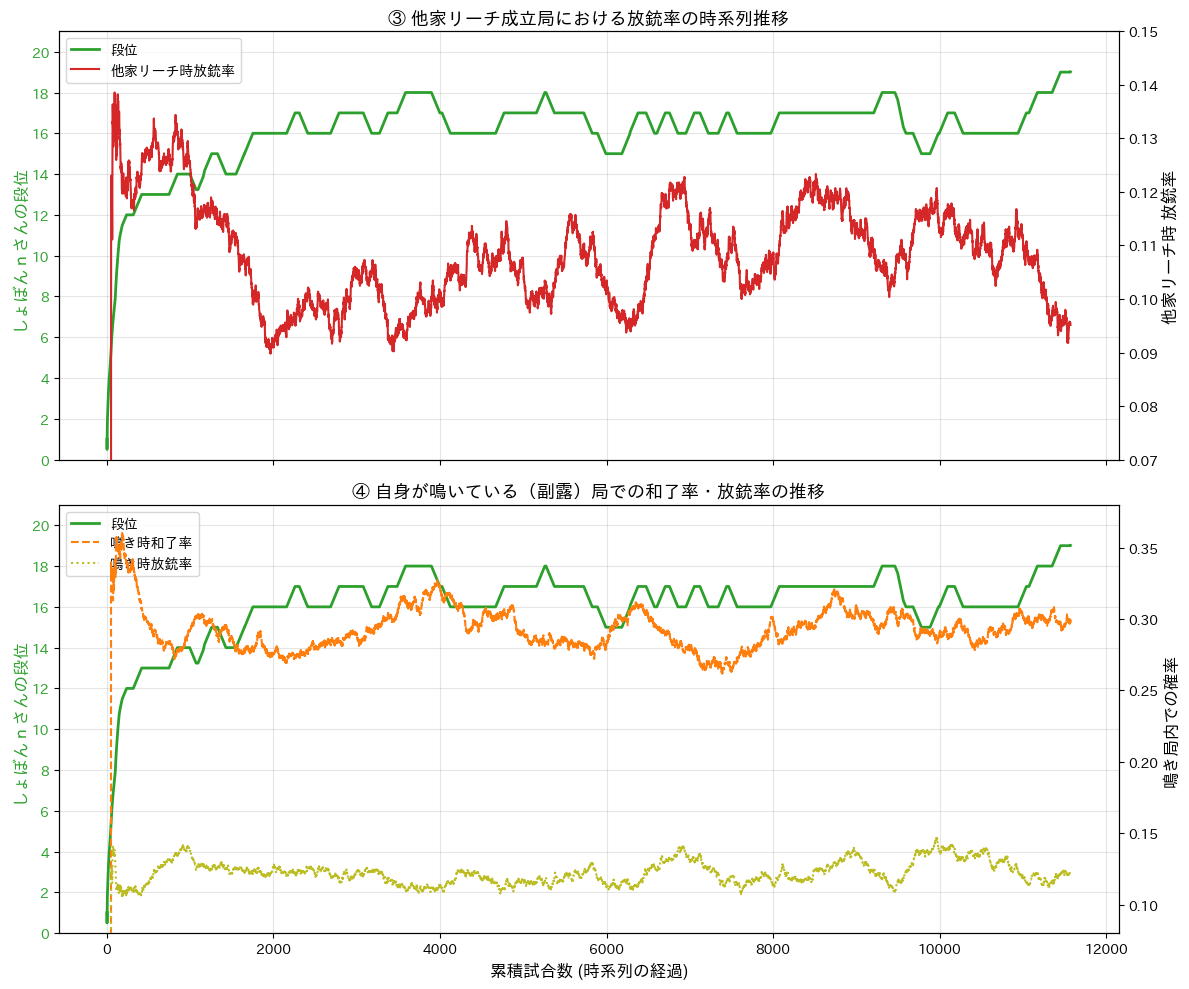

処理完了。有事の正規トレンドラインが完全に描画されました！


In [6]:
import matplotlib.pyplot as plt
import japanize_matplotlib
import matplotlib.ticker as ticker
import pandas as pd
import numpy as np
import gc

print("1. 試合内の局を完璧に同期させるクリーンな局ID（round_id）を作成中...")

# 確実に型を揃える
df['who_num'] = pd.to_numeric(df['who'], errors='coerce')
df['fromWho_num'] = pd.to_numeric(df['fromWho'], errors='coerce')
df['shobon_seat_num'] = pd.to_numeric(df['file_id'].map(shobon_map), errors='coerce')

# 基本的な和了・放銃フラグ
df['is_agari_raw'] = np.where((df['tag_type'] == 'AGARI') & (df['who_num'] == df['shobon_seat_num']), 1, 0)
df['is_hoju_raw'] = np.where(
    (df['tag_type'] == 'AGARI') &
    (df['fromWho_num'] == df['shobon_seat_num']) &
    (df['who_num'] != df['shobon_seat_num']),
    1, 0
)

# 【ここが修正のキモ】seedを使わず、INITタグの登場回数で局を完全にグルーピングする
df['is_init_raw'] = np.where(df['tag_type'] == 'INIT', 1, 0)
df['round_counter'] = df.groupby('file_id')['is_init_raw'].cumsum()
# 試合IDと局カウンターを組み合わせて、全行でズレないユニークな局IDを作成
df['round_id'] = df['file_id'].astype(str) + "_" + df['round_counter'].astype(str)

print("2. 局IDをベースに、他家リーチ・自身の鳴きが発生した局を仕分け中...")

# ③ 他家がリーチ成立（step=2）かつ、自分以外の局IDをセット化
other_reach_round_set = set(df[
    (df['tag_type'] == 'REACH') &
    (df['step'].astype(str) == '2') &
    (df['who_num'] != df['shobon_seat_num'])
]['round_id'].unique())

# ④ 自分が鳴いた（Nタグかつwhoが自分）局IDをセット化
my_furo_round_set = set(df[
    (df['tag_type'] == 'N') &
    (df['who_num'] == df['shobon_seat_num'])
]['round_id'].unique())

# 各行が該当する局に属しているかの判定フラグ
df['in_other_reach_round'] = df['round_id'].apply(lambda x: 1 if x in other_reach_round_set else 0)
df['in_my_furo_round'] = df['round_id'].apply(lambda x: 1 if x in my_furo_round_set else 0)

# 各有事の「分母（総局数）」をINIT行だけでカウント
df['init_other_reach'] = np.where((df['is_init_raw'] == 1) & (df['in_other_reach_round'] == 1), 1, 0)
df['init_my_furo'] = np.where((df['is_init_raw'] == 1) & (df['in_my_furo_round'] == 1), 1, 0)

# 各有事の「分子（和了・放銃）」をAGARI行だけでカウント
df['hoju_in_other_reach'] = np.where((df['is_hoju_raw'] == 1) & (df['in_other_reach_round'] == 1), 1, 0)
df['agari_in_my_furo'] = np.where((df['is_agari_raw'] == 1) & (df['in_my_furo_round'] == 1), 1, 0)
df['hoju_in_my_furo'] = np.where((df['is_hoju_raw'] == 1) & (df['in_my_furo_round'] == 1), 1, 0)

print("3. 試合単位にグループ化し、直近500試合の移動平均を計算中...")
game_situational_df = df.groupby('file_id').agg(
    reach_rounds=('init_other_reach', 'sum'),
    reach_hoju=('hoju_in_other_reach', 'sum'),
    furo_rounds=('init_my_furo', 'sum'),
    furo_agari=('agari_in_my_furo', 'sum'),
    furo_hoju=('hoju_in_my_furo', 'sum'),
    shobon_dan=('shobon_dan', 'median')
).reset_index()

# 時系列ソート
game_situational_df = game_situational_df.sort_values('file_id').reset_index(drop=True)
gc.collect()

match_window = 500
roll_reach_rounds = game_situational_df['reach_rounds'].rolling(window=match_window, min_periods=50).sum()
roll_reach_hoju = game_situational_df['reach_hoju'].rolling(window=match_window, min_periods=50).sum()

roll_furo_rounds = game_situational_df['furo_rounds'].rolling(window=match_window, min_periods=50).sum()
roll_furo_agari = game_situational_df['furo_agari'].rolling(window=match_window, min_periods=50).sum()
roll_furo_hoju = game_situational_df['furo_hoju'].rolling(window=match_window, min_periods=50).sum()

# 局ベースの正確な確率に変換
game_situational_df['rolling_other_reach_hoju_rate'] = (roll_reach_hoju / roll_reach_rounds).fillna(0)
game_situational_df['rolling_my_furo_agari_rate'] = (roll_furo_agari / roll_furo_rounds).fillna(0)
game_situational_df['rolling_my_furo_hoju_rate'] = (roll_furo_hoju / roll_furo_rounds).fillna(0)
game_situational_df['rolling_dan'] = game_situational_df['shobon_dan'].rolling(window=100, min_periods=1).mean()

print("4. グラフを描画中...")
fig, (ax_box1, ax_box2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
x_axis = game_situational_df.index

# --- グラフ1: ③ 他家リーチ時の放銃率 ---
color_dan = '#2ca02c'
ax_box1.set_ylabel('しょぼんｎさんの段位', color=color_dan, fontsize=12)
ax_box1.plot(x_axis, game_situational_df['rolling_dan'], color=color_dan, linewidth=2, label='段位')
ax_box1.tick_params(axis='y', labelcolor=color_dan)
ax_box1.set_ylim(0, 21)
ax_box1.yaxis.set_major_locator(ticker.MultipleLocator(2))

ax1_twin = ax_box1.twinx()
color_reach_hoju = '#d62728'
ax1_twin.set_ylabel('他家リーチ時 放銃率', color='black', fontsize=12)
ax1_twin.plot(x_axis, game_situational_df['rolling_other_reach_hoju_rate'], color=color_reach_hoju, linestyle='-', linewidth=1.5, label='他家リーチ時放銃率')
ax1_twin.tick_params(axis='y', labelcolor='black')
ax1_twin.set_ylim(0.07, 0.15)  # 一般的な他家リーチ時放銃率（10%〜20%強）のレンジに固定

ax_box1.set_title('③ 他家リーチ成立局における放銃率の時系列推移', fontsize=13, fontweight='bold')
lines1, labels1 = ax_box1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax_box1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax_box1.grid(True, which='both', axis='both', color='gray', linestyle='-', alpha=0.2)
ax1_twin.grid(False)


# --- グラフ2: ④ 鳴き（副露）時のスタッツ ---
ax_box2.set_xlabel('累積試合数 (時系列の経過)', fontsize=12)
ax_box2.set_ylabel('しょぼんｎさんの段位', color=color_dan, fontsize=12)
ax_box2.plot(x_axis, game_situational_df['rolling_dan'], color=color_dan, linewidth=2, label='段位')
ax_box2.tick_params(axis='y', labelcolor=color_dan)
ax_box2.set_ylim(0, 21)
ax_box2.yaxis.set_major_locator(ticker.MultipleLocator(2))

ax2_twin = ax_box2.twinx()
color_furo_agari = '#ff7f0e'
color_furo_hoju = '#bcbd22'
ax2_twin.set_ylabel('鳴き局内での確率', color='black', fontsize=12)
ax2_twin.plot(x_axis, game_situational_df['rolling_my_furo_agari_rate'], color=color_furo_agari, linestyle='--', linewidth=1.5, label='鳴き時和了率')
ax2_twin.plot(x_axis, game_situational_df['rolling_my_furo_hoju_rate'], color=color_furo_hoju, linestyle=':', linewidth=1.5, label='鳴き時放銃率')
ax2_twin.tick_params(axis='y', labelcolor='black')
ax2_twin.set_ylim(0.08, 0.38)  # 鳴き時和了（約30%前後）のレンジに固定

ax_box2.set_title('④ 自身が鳴いている（副露）局での和了率・放銃率の推移', fontsize=13, fontweight='bold')
lines3, labels3 = ax_box2.get_legend_handles_labels()
lines4, labels4 = ax2_twin.get_legend_handles_labels()
ax_box2.legend(lines3 + lines4, labels3 + labels4, loc='upper left')
ax_box2.grid(True, which='both', axis='both', color='gray', linestyle='-', alpha=0.2)
ax2_twin.grid(False)

plt.tight_layout()
plt.show()

plt.close(fig)
gc.collect()
print("処理完了。有事の正規トレンドラインが完全に描画されました！")